In [2]:
# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.nn.utils.rnn import pad_sequence

# Data Processing
import numpy as np
import pandas as pd
import re
from collections import Counter

# NLP
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    roc_curve, auc, f1_score, recall_score, precision_score
)
from sklearn.preprocessing import label_binarize

# Utilities
import os
import json
import time
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Download NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

print("Libraries loaded")

Libraries loaded


In [3]:
print("="*80)
print("ENVIRONMENT VERIFICATION")
print("="*80)

print(f"\nPyTorch Version: {torch.__version__}")

if torch.cuda.is_available():
    print(f"CUDA Available: {torch.cuda.is_available()}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    
    for i in range(torch.cuda.device_count()):
        gpu_name = torch.cuda.get_device_name(i)
        gpu_memory = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f"\n   GPU {i}: {gpu_name}")
        print(f"   Memory: {gpu_memory:.2f} GB")
    
    device = torch.device('cuda:0')
    print(f"\nUsing device: {device}")
    print(f"Selected: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA not available. Using CPU.")
    device = torch.device('cpu')

print("\n" + "="*80)
print("Environment ready")
print("="*80)

ENVIRONMENT VERIFICATION

PyTorch Version: 2.1.2+cu118
CUDA Available: True
Number of GPUs: 2

   GPU 0: NVIDIA RTX A6000
   Memory: 51.53 GB

   GPU 1: NVIDIA RTX A6000
   Memory: 51.53 GB

Using device: cuda:0
Selected: NVIDIA RTX A6000

Environment ready


In [19]:
CONFIG = {
    # Paths
    'DATA_PATH': r'C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\data\Tweets.csv',
    'OUTPUT_DIR': r'C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q2\Q2a_LSTM_Sentiment_PyTorch',
    
     # ========== TEXT PROCESSING ==========
    'MAX_VOCAB_SIZE': 10000,  # Top 10K most common words
    'MAX_SEQ_LENGTH': 50,      # Max words per tweet
    'MIN_WORD_FREQ': 2,        # Ignore words appearing less than this
    
    # ========== MODEL HYPERPARAMETERS ==========
    # Embedding settings
    'EMBEDDING_DIM': 128,      # Word vector dimension
    
    # LSTM settings
    'HIDDEN_DIM': 256,         # LSTM hidden state size
    'NUM_LAYERS': 2,           # Number of LSTM layers
    'DROPOUT': 0.5,            # Dropout probability
    'BIDIRECTIONAL': True,     # Use Bi-LSTM (captures context both ways)
    
    # Training settings
    'BATCH_SIZE': 64,          # Batch size for training
    'LEARNING_RATE': 0.001,    # Initial learning rate
    'MAX_EPOCHS': 50,          # Maximum epochs (early stopping will cut this)
    
    # Classes
    'NUM_CLASSES': 3,
    'CLASS_NAMES': ['negative', 'neutral', 'positive'],
    
    # ========== DATA SPLIT ==========
    'TRAIN_SPLIT': 0.8,  # 80% for training
    'VAL_SPLIT': 0.1,    # 10% for validation
    'TEST_SPLIT': 0.1,   # 10% for testing
    
    # ========== EARLY STOPPING ==========
    'EARLY_STOP_PATIENCE': 7,  # Stop if no improvement for 7 epochs
    'EARLY_STOP_MIN_DELTA': 0.001,  # Minimum improvement threshold (0.1%)
    
    # ========== LEARNING RATE SCHEDULER ==========
    'LR_PATIENCE': 3,  # Reduce LR if no improvement for 3 epochs
    'LR_FACTOR': 0.5,  # Reduce LR by 50%
    
    # ========== MISC ==========
    'RANDOM_SEED': 42,
    'NUM_WORKERS': 0,  # Set to 0 for Windows compatibility
}

# Set random seeds for reproducibility
torch.manual_seed(CONFIG['RANDOM_SEED'])
np.random.seed(CONFIG['RANDOM_SEED'])
if torch.cuda.is_available():
    torch.cuda.manual_seed(CONFIG['RANDOM_SEED'])

# Create output directory
os.makedirs(CONFIG['OUTPUT_DIR'], exist_ok=True)

# Verify data file exists
if not os.path.exists(CONFIG['DATA_PATH']):
    print("\nERROR: Data file not found!")
    print(f"   Looking for: {CONFIG['DATA_PATH']}")
    print(f"\n   FIX: Update CONFIG['DATA_PATH'] to correct path")
    print(f"   Current directory: {Path.cwd()}")
else:
    print("\nConfiguration loaded successfully!")
    print(f"\nPaths:")
    print(f"   Data: {CONFIG['DATA_PATH']}")
    print(f"   Output: {CONFIG['OUTPUT_DIR']}")
    
    print(f"\nText Processing Settings:")
    print(f"   Vocabulary size: {CONFIG['MAX_VOCAB_SIZE']:,}")
    print(f"   Max sequence length: {CONFIG['MAX_SEQ_LENGTH']} words")
    print(f"   Embedding dimension: {CONFIG['EMBEDDING_DIM']}")
    
    print(f"\nModel Architecture:")
    print(f"   LSTM hidden dim: {CONFIG['HIDDEN_DIM']}")
    print(f"   LSTM layers: {CONFIG['NUM_LAYERS']}")
    print(f"   Bidirectional: {CONFIG['BIDIRECTIONAL']}")
    print(f"   Dropout: {CONFIG['DROPOUT']}")
    
    print(f"\nTraining Settings:")
    print(f"   Batch size: {CONFIG['BATCH_SIZE']}")
    print(f"   Learning rate: {CONFIG['LEARNING_RATE']}")
    print(f"   Max epochs: {CONFIG['MAX_EPOCHS']} (with early stopping)")
    
    print(f"\nEarly Stopping:")
    print(f"   Patience: {CONFIG['EARLY_STOP_PATIENCE']} epochs")
    print(f"   Min improvement: {CONFIG['EARLY_STOP_MIN_DELTA']*100:.1f}%")


Configuration loaded successfully!

Paths:
   Data: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\data\Tweets.csv
   Output: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q2\Q2a_LSTM_Sentiment_PyTorch

Text Processing Settings:
   Vocabulary size: 10,000
   Max sequence length: 50 words
   Embedding dimension: 128

Model Architecture:
   LSTM hidden dim: 256
   LSTM layers: 2
   Bidirectional: True
   Dropout: 0.5

Training Settings:
   Batch size: 64
   Learning rate: 0.001
   Max epochs: 50 (with early stopping)

Early Stopping:
   Patience: 7 epochs
   Min improvement: 0.1%


In [20]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_epoch = 0
        
    def __call__(self, val_loss, epoch):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_epoch = epoch
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.best_epoch = epoch
            self.counter = 0
        
        return self.early_stop


class MetricTracker:
    def __init__(self):
        self.history = {
            'epoch': [],
            'train_loss': [],
            'train_acc': [],
            'val_loss': [],
            'val_acc': [],
            'val_f1': [],
            'val_precision': [],
            'val_recall': [],
            'learning_rate': [],
            'epoch_time': []
        }
    
    def update(self, epoch, metrics):
        self.history['epoch'].append(epoch)
        for key, value in metrics.items():
            if key in self.history:
                self.history[key].append(value)
    
    def get_best(self, metric='val_acc', mode='max'):
        if mode == 'max':
            return max(self.history[metric])
        else:
            return min(self.history[metric])
    
    def save_csv(self, filepath):
        df = pd.DataFrame(self.history)
        df.to_csv(filepath, index=False)


def format_time(seconds):
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    secs = int(seconds % 60)
    
    if hours > 0:
        return f"{hours}h {minutes}m {secs}s"
    elif minutes > 0:
        return f"{minutes}m {secs}s"
    else:
        return f"{secs}s"


def print_training_summary(epoch, total_epochs, metrics, epoch_time):
    print(f"\n{'='*80}")
    print(f"Epoch {epoch}/{total_epochs} - {format_time(epoch_time)}")
    print(f"{'='*80}")
    print(f"Train Loss: {metrics['train_loss']:.4f} | Train Acc: {metrics['train_acc']:.2f}%")
    print(f"Val Loss:   {metrics['val_loss']:.4f} | Val Acc:   {metrics['val_acc']:.2f}%")
    print(f"Val F1:     {metrics['val_f1']:.4f} | Precision:  {metrics['val_precision']:.4f} | Recall: {metrics['val_recall']:.4f}")
    print(f"Learning Rate: {metrics['learning_rate']:.6f}")


print("Helper functions defined successfully!")
print("\nAvailable utilities:")
print("  • EarlyStopping - Automatic training termination")
print("  • MetricTracker - Records all training metrics")
print("  • format_time - Human-readable time formatting")
print("  • print_training_summary - Clean progress display")

Helper functions defined successfully!

Available utilities:
  • EarlyStopping - Automatic training termination
  • MetricTracker - Records all training metrics
  • format_time - Human-readable time formatting
  • print_training_summary - Clean progress display


Loading dataset...

Dataset loaded successfully!
   Total samples: 14,640
   Columns: 15

DATASET INFORMATION

Dataset shape: (14640, 15)

Column names:
['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']

First few rows:
             tweet_id airline_sentiment  airline_sentiment_confidence  \
0  570306133677760513           neutral                        1.0000   
1  570301130888122368          positive                        0.3486   
2  570301083672813571           neutral                        0.6837   
3  570301031407624196          negative                        1.0000   
4  570300817074462722          negative                        1.0000   

  negativereason  negativereason_confidence         airline  \
0            NaN                        NaN  Virgin Ame

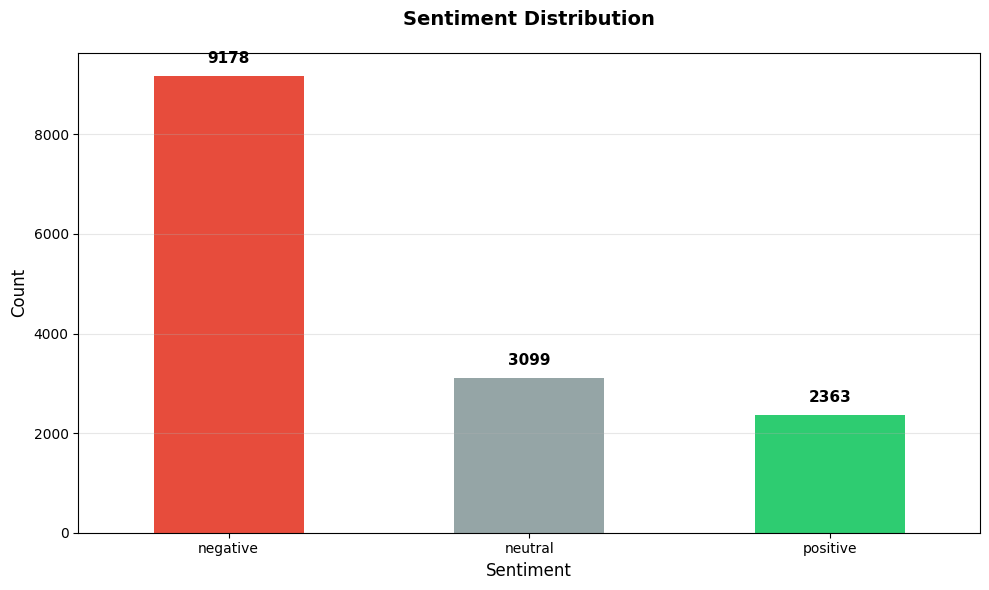


TEXT LENGTH STATISTICS

Character length statistics:
count    14640.000000
mean       103.822063
std         36.277339
min         12.000000
25%         77.000000
50%        114.000000
75%        136.000000
max        186.000000
Name: text_length, dtype: float64

Word count statistics:
count    14640.000000
mean        17.653415
std          6.882259
min          2.000000
25%         12.000000
50%         19.000000
75%         23.000000
max         36.000000
Name: word_count, dtype: float64

SAMPLE TWEETS FROM EACH CLASS

NEGATIVE examples:
--------------------------------------------------------------------------------
1. @VirginAmerica it's really aggressive to blast obnoxious "entertainment" in your guests' faces &amp; they have little recourse
2. @VirginAmerica and it's a really big bad thing about it
3. @VirginAmerica seriously would pay $30 a flight for seats that didn't have this playing.
it's really the only bad thing about flying VA

NEUTRAL examples:
------------------------

In [21]:
print("Loading dataset...\n")

# Load CSV file
df = pd.read_csv(CONFIG['DATA_PATH'])

print(f"Dataset loaded successfully!")
print(f"   Total samples: {len(df):,}")
print(f"   Columns: {len(df.columns)}")

print("\n" + "="*80)
print("DATASET INFORMATION")
print("="*80)

print("\nDataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst few rows:")
print(df.head())

print("\nDataset info:")
print(df.info())

# Check for missing values
print("\n" + "="*80)
print("MISSING VALUES CHECK")
print("="*80)
missing = df.isnull().sum()
missing = missing[missing > 0]
if len(missing) > 0:
    print("\nMissing values found:")
    print(missing)
else:
    print("\nNo missing values found")

# Sentiment distribution
print("\n" + "="*80)
print("SENTIMENT DISTRIBUTION")
print("="*80)
print("\nClass counts:")
sentiment_counts = df['airline_sentiment'].value_counts()
print(sentiment_counts)

print("\nClass percentages:")
sentiment_pct = df['airline_sentiment'].value_counts(normalize=True) * 100
for sentiment, pct in sentiment_pct.items():
    print(f"   {sentiment:10s}: {pct:6.2f}%")

# Visualize distribution
plt.figure(figsize=(10, 6))
sentiment_counts.plot(kind='bar', color=['#e74c3c', '#95a5a6', '#2ecc71'])
plt.title('Sentiment Distribution', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add counts on top of bars
for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v + 200, str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
dist_path = os.path.join(CONFIG['OUTPUT_DIR'], 'sentiment_distribution.png')
plt.savefig(dist_path, dpi=150, bbox_inches='tight')
print(f"\nSentiment distribution plot saved to: {dist_path}")
plt.show()

# Text length statistics
print("\n" + "="*80)
print("TEXT LENGTH STATISTICS")
print("="*80)
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print("\nCharacter length statistics:")
print(df['text_length'].describe())

print("\nWord count statistics:")
print(df['word_count'].describe())

# Sample tweets from each class
print("\n" + "="*80)
print("SAMPLE TWEETS FROM EACH CLASS")
print("="*80)

for sentiment in CONFIG['CLASS_NAMES']:
    print(f"\n{sentiment.upper()} examples:")
    print("-" * 80)
    samples = df[df['airline_sentiment'] == sentiment]['text'].head(3)
    for i, text in enumerate(samples, 1):
        print(f"{i}. {text}")

In [22]:
def clean_text(text):
    """
    Comprehensive text cleaning for tweets
    
    Steps:
    1. Convert to string (handle any non-string data)
    2. Remove URLs (http/https links)
    3. Remove @mentions
    4. Remove hashtag symbols (keep the word)
    5. Remove special characters and numbers
    6. Convert to lowercase
    7. Remove extra whitespace
    8. Remove very short words (< 2 chars)
    
    Returns:
    - Cleaned text string
    """
    # Convert to string
    text = str(text)
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove @mentions
    text = re.sub(r'@\w+', '', text)
    
    # Remove hashtag symbols but keep the word
    text = re.sub(r'#', '', text)
    
    # Remove RT (retweet marker)
    text = re.sub(r'\bRT\b', '', text, flags=re.IGNORECASE)
    
    # Remove special characters, numbers, and punctuation
    # Keep only letters and spaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    # Remove very short words (often noise)
    words = text.split()
    words = [w for w in words if len(w) >= 2]
    text = ' '.join(words)
    
    return text


print("Cleaning text data...\n")
print("This may take 1-2 minutes...\n")

# Create clean dataframe
df_clean = df[['text', 'airline_sentiment']].copy()

# Remove rows with missing text
original_size = len(df_clean)
df_clean = df_clean.dropna(subset=['text'])
print(f"Removed {original_size - len(df_clean)} rows with missing text")

# Apply cleaning
df_clean['text_clean'] = df_clean['text'].apply(clean_text)

# Remove empty texts after cleaning
df_clean = df_clean[df_clean['text_clean'].str.len() > 0]
print(f"Dataset size after cleaning: {len(df_clean):,}")

# Show cleaning examples
print("\n" + "="*80)
print("CLEANING EXAMPLES (Before → After)")
print("="*80)

for i in range(5):
    print(f"\n{i+1}. ORIGINAL:")
    print(f"   {df_clean['text'].iloc[i]}")
    print(f"   CLEANED:")
    print(f"   {df_clean['text_clean'].iloc[i]}")

# Text length comparison
print("\n" + "="*80)
print("TEXT LENGTH COMPARISON")
print("="*80)

df_clean['original_length'] = df_clean['text'].str.len()
df_clean['cleaned_length'] = df_clean['text_clean'].str.len()

print("\nOriginal text length:")
print(df_clean['original_length'].describe())

print("\nCleaned text length:")
print(df_clean['cleaned_length'].describe())

reduction = (1 - df_clean['cleaned_length'].mean() / df_clean['original_length'].mean()) * 100
print(f"\nAverage length reduction: {reduction:.1f}%")

# Map sentiment to numeric labels
print("\n" + "="*80)
print("LABEL ENCODING")
print("="*80)

sentiment_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df_clean['label'] = df_clean['airline_sentiment'].map(sentiment_map)

print("\nSentiment → Label mapping:")
for sentiment, label in sentiment_map.items():
    count = (df_clean['label'] == label).sum()
    print(f"   {sentiment:10s} → {label} ({count:,} samples)")

print("\nLabel distribution:")
print(df_clean['label'].value_counts().sort_index())

print("\nText preprocessing complete!")


Cleaning text data...

This may take 1-2 minutes...

Removed 0 rows with missing text
Dataset size after cleaning: 14,639

CLEANING EXAMPLES (Before → After)

1. ORIGINAL:
   @VirginAmerica What @dhepburn said.
   CLEANED:
   what said

2. ORIGINAL:
   @VirginAmerica plus you've added commercials to the experience... tacky.
   CLEANED:
   plus youve added commercials to the experience tacky

3. ORIGINAL:
   @VirginAmerica I didn't today... Must mean I need to take another trip!
   CLEANED:
   didnt today must mean need to take another trip

4. ORIGINAL:
   @VirginAmerica it's really aggressive to blast obnoxious "entertainment" in your guests' faces &amp; they have little recourse
   CLEANED:
   its really aggressive to blast obnoxious entertainment in your guests faces amp they have little recourse

5. ORIGINAL:
   @VirginAmerica and it's a really big bad thing about it
   CLEANED:
   and its really big bad thing about it

TEXT LENGTH COMPARISON

Original text length:
count    14639.0

In [23]:
print("Building vocabulary...\n")

# Tokenize all texts and count word frequencies
all_words = []
for text in df_clean['text_clean']:
    words = text.split()
    all_words.extend(words)

print(f"Total words in corpus: {len(all_words):,}")

# Count word frequencies
word_counts = Counter(all_words)
print(f"Unique words: {len(word_counts):,}")

# Filter by minimum frequency
word_counts_filtered = {word: count for word, count in word_counts.items() 
                       if count >= CONFIG['MIN_WORD_FREQ']}
print(f"Words after filtering (freq >= {CONFIG['MIN_WORD_FREQ']}): {len(word_counts_filtered):,}")

# Build vocabulary (most common words)
vocab = ['<PAD>', '<UNK>']  # Special tokens
most_common = [word for word, count in 
               Counter(word_counts_filtered).most_common(CONFIG['MAX_VOCAB_SIZE'] - 2)]
vocab.extend(most_common)

print(f"\nFinal vocabulary size: {len(vocab):,}")

# Create word-to-index and index-to-word mappings
word_to_idx = {word: idx for idx, word in enumerate(vocab)}
idx_to_word = {idx: word for word, idx in word_to_idx.items()}

# Vocabulary statistics
print("\n" + "="*80)
print("VOCABULARY STATISTICS")
print("="*80)

print(f"\nTotal unique words in corpus: {len(word_counts):,}")
print(f"Vocabulary size (after filtering): {len(vocab):,}")
print(f"Coverage: {len(vocab) / len(word_counts) * 100:.2f}%")

print("\nMost common words (Top 30):")
most_common_30 = word_counts.most_common(30)
for i, (word, count) in enumerate(most_common_30, 1):
    print(f"   {i:2d}. {word:15s} ({count:5d} occurrences)")

print("\nLeast common words (examples):")
least_common = sorted(word_counts.items(), key=lambda x: x[1])[:10]
for word, count in least_common:
    print(f"   {word:15s} ({count} occurrences)")

# Word length distribution in vocabulary
word_lengths = [len(word) for word in vocab if word not in ['<PAD>', '<UNK>']]
print(f"\nWord length statistics:")
print(f"   Mean: {np.mean(word_lengths):.2f} characters")
print(f"   Median: {np.median(word_lengths):.0f} characters")
print(f"   Max: {np.max(word_lengths)} characters")
print(f"   Min: {np.min(word_lengths)} characters")


def text_to_sequence(text, word_to_idx, max_length):
    """
    Convert text to sequence of word indices
    
    Steps:
    1. Split text into words
    2. Convert each word to its index (use <UNK> for unknown words)
    3. Pad or truncate to max_length
    
    Parameters:
    - text: Input text string
    - word_to_idx: Dictionary mapping words to indices
    - max_length: Maximum sequence length
    
    Returns:
    - List of word indices
    """
    words = text.split()
    
    # Convert words to indices
    sequence = []
    for word in words:
        if word in word_to_idx:
            sequence.append(word_to_idx[word])
        else:
            sequence.append(word_to_idx['<UNK>'])  # Unknown word
    
    # Pad or truncate
    if len(sequence) < max_length:
        # Pad with <PAD> token
        sequence = sequence + [word_to_idx['<PAD>']] * (max_length - len(sequence))
    else:
        # Truncate to max_length
        sequence = sequence[:max_length]
    
    return sequence


print("\n" + "="*80)
print("TOKENIZING TEXTS")
print("="*80)

df_clean['sequence'] = df_clean['text_clean'].apply(
    lambda x: text_to_sequence(x, word_to_idx, CONFIG['MAX_SEQ_LENGTH'])
)

# Calculate coverage (percentage of known words)
total_words = 0
known_words = 0

for text in df_clean['text_clean']:
    words = text.split()
    total_words += len(words)
    known_words += sum(1 for word in words if word in word_to_idx)

coverage = known_words / total_words * 100 if total_words > 0 else 0
print(f"\nVocabulary coverage: {coverage:.2f}%")
print(f"   Known words: {known_words:,}")
print(f"   Total words: {total_words:,}")
print(f"   Unknown words: {total_words - known_words:,}")

# Tokenization examples
print("\n" + "="*80)
print("TOKENIZATION EXAMPLES")
print("="*80)

for i in range(3):
    text = df_clean['text_clean'].iloc[i]
    sequence = df_clean['sequence'].iloc[i]
    label = df_clean['airline_sentiment'].iloc[i]
    
    print(f"\n{i+1}. Text: {text}")
    print(f"   Sentiment: {label}")
    print(f"   Sequence (first 15 tokens): {sequence[:15]}")
    
    # Decode sequence back to words (for verification)
    words = [idx_to_word[idx] for idx in sequence[:15]]
    print(f"   Decoded: {' '.join(words)}")

print("\nVocabulary and tokenization complete!")

Building vocabulary...

Total words in corpus: 222,190
Unique words: 12,532
Words after filtering (freq >= 2): 5,751

Final vocabulary size: 5,753

VOCABULARY STATISTICS

Total unique words in corpus: 12,532
Vocabulary size (after filtering): 5,753
Coverage: 45.91%

Most common words (Top 30):
    1. to              ( 8643 occurrences)
    2. the             ( 6053 occurrences)
    3. you             ( 4110 occurrences)
    4. for             ( 3995 occurrences)
    5. flight          ( 3895 occurrences)
    6. on              ( 3778 occurrences)
    7. and             ( 3709 occurrences)
    8. my              ( 3273 occurrences)
    9. is              ( 2827 occurrences)
   10. in              ( 2529 occurrences)
   11. of              ( 2121 occurrences)
   12. me              ( 1913 occurrences)
   13. it              ( 1880 occurrences)
   14. your            ( 1738 occurrences)
   15. have            ( 1642 occurrences)
   16. was             ( 1606 occurrences)
   17. not       

Visualizing sample texts from each class...

Sample visualization saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q2\Q2a_LSTM_Sentiment_PyTorch\sample_texts.png


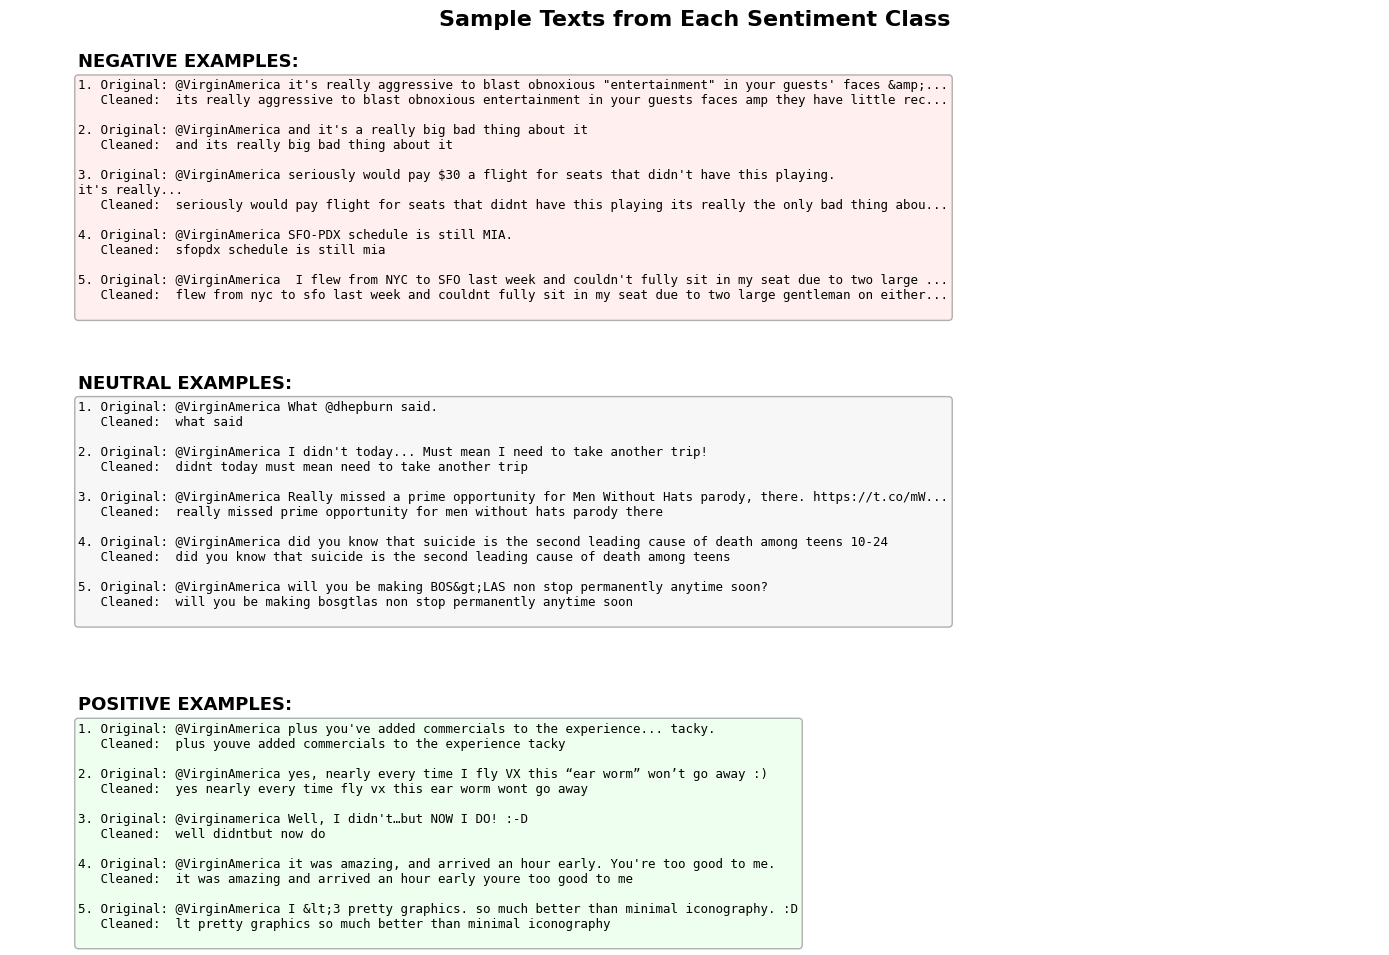


CLASS DISTRIBUTION SUMMARY
   negative  :  9178 samples (62.70%)
   neutral   :  3099 samples (21.17%)
   positive  :  2362 samples (16.13%)
Preparing data loaders...

Total samples: 14,639
Sequence shape: (14639, 50)
Labels shape: (14639,)

DATASET SPLIT

Training:   11,711 samples (80.0%)
Validation: 1,463 samples (10.0%)
Test:       1,465 samples (10.0%)

CLASS DISTRIBUTION IN SPLITS

Training set:
   negative  :  7315 samples (62.46%)
   neutral   :  2502 samples (21.36%)
   positive  :  1894 samples (16.17%)

Validation set:
   negative  :   935 samples (63.91%)
   neutral   :   300 samples (20.51%)
   positive  :   228 samples (15.58%)

Test set:
   negative  :   928 samples (63.34%)
   neutral   :   297 samples (20.27%)
   positive  :   240 samples (16.38%)

PYTORCH TENSORS

Train tensors:
   X_train shape: torch.Size([11711, 50])
   y_train shape: torch.Size([11711])

Validation tensors:
   X_val shape: torch.Size([1463, 50])
   y_val shape: torch.Size([1463])

Test tensors:
 

In [26]:
print("Visualizing sample texts from each class...\n")

# Create visualization
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for idx, (sentiment, label) in enumerate(sentiment_map.items()):
    # Get samples from this class
    class_samples = df_clean[df_clean['label'] == label].head(5)
    
    # Prepare text for display
    texts = []
    for i, (_, row) in enumerate(class_samples.iterrows(), 1):
        original = row['text'][:100] + '...' if len(row['text']) > 100 else row['text']
        cleaned = row['text_clean'][:100] + '...' if len(row['text_clean']) > 100 else row['text_clean']
        texts.append(f"{i}. Original: {original}\n   Cleaned:  {cleaned}\n")
    
    # Create text display
    display_text = '\n'.join(texts)
    
    # Color based on sentiment
    colors = {'negative': '#ffcccc', 'neutral': '#e6e6e6', 'positive': '#ccffcc'}
    
    axes[idx].text(0.05, 0.95, f"{sentiment.upper()} EXAMPLES:",
                  transform=axes[idx].transAxes,
                  fontsize=13, fontweight='bold',
                  verticalalignment='top')
    
    axes[idx].text(0.05, 0.85, display_text,
                  transform=axes[idx].transAxes,
                  fontsize=9, family='monospace',
                  verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor=colors[sentiment], alpha=0.3))
    
    axes[idx].axis('off')

plt.suptitle('Sample Texts from Each Sentiment Class', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()

sample_path = os.path.join(CONFIG['OUTPUT_DIR'], 'sample_texts.png')
plt.savefig(sample_path, dpi=150, bbox_inches='tight')
print(f"Sample visualization saved to: {sample_path}")
plt.show()

# Print class distribution for splits
print("\n" + "="*80)
print("CLASS DISTRIBUTION SUMMARY")
print("="*80)

for sentiment, label in sentiment_map.items():
    count = (df_clean['label'] == label).sum()
    percentage = count / len(df_clean) * 100
    print(f"   {sentiment:10s}: {count:5d} samples ({percentage:5.2f}%)")




print("Preparing data loaders...\n")

# Convert to numpy arrays
sequences = np.array(df_clean['sequence'].tolist())
labels = df_clean['label'].values

print(f"Total samples: {len(sequences):,}")
print(f"Sequence shape: {sequences.shape}")
print(f"Labels shape: {labels.shape}")

# Shuffle data
np.random.seed(CONFIG['RANDOM_SEED'])
indices = np.random.permutation(len(sequences))
sequences = sequences[indices]
labels = labels[indices]

# Split data
n_samples = len(sequences)
train_end = int(CONFIG['TRAIN_SPLIT'] * n_samples)
val_end = train_end + int(CONFIG['VAL_SPLIT'] * n_samples)

X_train = sequences[:train_end]
y_train = labels[:train_end]

X_val = sequences[train_end:val_end]
y_val = labels[train_end:val_end]

X_test = sequences[val_end:]
y_test = labels[val_end:]

print("\n" + "="*80)
print("DATASET SPLIT")
print("="*80)
print(f"\nTraining:   {len(X_train):,} samples ({len(X_train)/n_samples*100:.1f}%)")
print(f"Validation: {len(X_val):,} samples ({len(X_val)/n_samples*100:.1f}%)")
print(f"Test:       {len(X_test):,} samples ({len(X_test)/n_samples*100:.1f}%)")

# Check class distribution in splits
print("\n" + "="*80)
print("CLASS DISTRIBUTION IN SPLITS")
print("="*80)

for split_name, split_labels in [('Training', y_train), 
                                   ('Validation', y_val), 
                                   ('Test', y_test)]:
    print(f"\n{split_name} set:")
    for sentiment, label in sentiment_map.items():
        count = np.sum(split_labels == label)
        percentage = count / len(split_labels) * 100
        print(f"   {sentiment:10s}: {count:5d} samples ({percentage:5.2f}%)")

# Convert to PyTorch tensors
X_train_tensor = torch.LongTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)

X_val_tensor = torch.LongTensor(X_val)
y_val_tensor = torch.LongTensor(y_val)

X_test_tensor = torch.LongTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

print("\n" + "="*80)
print("PYTORCH TENSORS")
print("="*80)
print(f"\nTrain tensors:")
print(f"   X_train shape: {X_train_tensor.shape}")
print(f"   y_train shape: {y_train_tensor.shape}")

print(f"\nValidation tensors:")
print(f"   X_val shape: {X_val_tensor.shape}")
print(f"   y_val shape: {y_val_tensor.shape}")

print(f"\nTest tensors:")
print(f"   X_test shape: {X_test_tensor.shape}")
print(f"   y_test shape: {y_test_tensor.shape}")

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['BATCH_SIZE'],
    shuffle=True,
    num_workers=CONFIG['NUM_WORKERS'],
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['BATCH_SIZE'],
    shuffle=False,
    num_workers=CONFIG['NUM_WORKERS'],
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['BATCH_SIZE'],
    shuffle=False,
    num_workers=CONFIG['NUM_WORKERS'],
    pin_memory=True if torch.cuda.is_available() else False
)

print("\n" + "="*80)
print("DATA LOADERS")
print("="*80)
print(f"\nBatches per epoch:")
print(f"   Training:   {len(train_loader)} batches")
print(f"   Validation: {len(val_loader)} batches")
print(f"   Test:       {len(test_loader)} batches")

print(f"\nEstimated time per epoch: ~{len(train_loader) * 0.8:.0f}s (on GPU)")

print("\nData loaders created successfully!")




print("Preparing data loaders...\n")

# Convert to numpy arrays
sequences = np.array(df_clean['sequence'].tolist())
labels = df_clean['label'].values

print(f"Total samples: {len(sequences):,}")
print(f"Sequence shape: {sequences.shape}")
print(f"Labels shape: {labels.shape}")

# Shuffle data
np.random.seed(CONFIG['RANDOM_SEED'])
indices = np.random.permutation(len(sequences))
sequences = sequences[indices]
labels = labels[indices]

# Split data
n_samples = len(sequences)
train_end = int(CONFIG['TRAIN_SPLIT'] * n_samples)
val_end = train_end + int(CONFIG['VAL_SPLIT'] * n_samples)

X_train = sequences[:train_end]
y_train = labels[:train_end]

X_val = sequences[train_end:val_end]
y_val = labels[train_end:val_end]

X_test = sequences[val_end:]
y_test = labels[val_end:]

print("\n" + "="*80)
print("DATASET SPLIT")
print("="*80)
print(f"\nTraining:   {len(X_train):,} samples ({len(X_train)/n_samples*100:.1f}%)")
print(f"Validation: {len(X_val):,} samples ({len(X_val)/n_samples*100:.1f}%)")
print(f"Test:       {len(X_test):,} samples ({len(X_test)/n_samples*100:.1f}%)")

# Check class distribution in splits
print("\n" + "="*80)
print("CLASS DISTRIBUTION IN SPLITS")
print("="*80)

for split_name, split_labels in [('Training', y_train), 
                                   ('Validation', y_val), 
                                   ('Test', y_test)]:
    print(f"\n{split_name} set:")
    for sentiment, label in sentiment_map.items():
        count = np.sum(split_labels == label)
        percentage = count / len(split_labels) * 100
        print(f"   {sentiment:10s}: {count:5d} samples ({percentage:5.2f}%)")

# Convert to PyTorch tensors
X_train_tensor = torch.LongTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)

X_val_tensor = torch.LongTensor(X_val)
y_val_tensor = torch.LongTensor(y_val)

X_test_tensor = torch.LongTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

print("\n" + "="*80)
print("PYTORCH TENSORS")
print("="*80)
print(f"\nTrain tensors:")
print(f"   X_train shape: {X_train_tensor.shape}")
print(f"   y_train shape: {y_train_tensor.shape}")

print(f"\nValidation tensors:")
print(f"   X_val shape: {X_val_tensor.shape}")
print(f"   y_val shape: {y_val_tensor.shape}")

print(f"\nTest tensors:")
print(f"   X_test shape: {X_test_tensor.shape}")
print(f"   y_test shape: {y_test_tensor.shape}")

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['BATCH_SIZE'],
    shuffle=True,
    num_workers=CONFIG['NUM_WORKERS'],
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['BATCH_SIZE'],
    shuffle=False,
    num_workers=CONFIG['NUM_WORKERS'],
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['BATCH_SIZE'],
    shuffle=False,
    num_workers=CONFIG['NUM_WORKERS'],
    pin_memory=True if torch.cuda.is_available() else False
)

print("\n" + "="*80)
print("DATA LOADERS")
print("="*80)
print(f"\nBatches per epoch:")
print(f"   Training:   {len(train_loader)} batches")
print(f"   Validation: {len(val_loader)} batches")
print(f"   Test:       {len(test_loader)} batches")

print(f"\nEstimated time per epoch: ~{len(train_loader) * 0.8:.0f}s (on GPU)")

print("\nData loaders created successfully!")

In [27]:
class SentimentLSTM(nn.Module):
    """
    LSTM Model for Sentiment Classification
    
    Architecture Overview:
    ┌─────────────────────────────────────────────────────┐
    │ Input: Sequence of word indices (batch, seq_len)   │
    ├─────────────────────────────────────────────────────┤
    │ Embedding Layer: vocab_size → embedding_dim        │
    │ Bidirectional LSTM Layers (2x)                     │
    │ Dropout                                            │
    │ Fully Connected Layer                              │
    │ Output: Class probabilities (batch, num_classes)   │
    └─────────────────────────────────────────────────────┘
    
    Key Features:
    - Bidirectional processing (captures context both ways)
    - Multi-layer LSTM (deeper representations)
    - Dropout regularization (prevents overfitting)
    - Trainable word embeddings
    """
    
    def __init__(self, vocab_size, embedding_dim, hidden_dim, 
                 num_layers, num_classes, dropout, bidirectional):
        super(SentimentLSTM, self).__init__()
        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        
        # ========== Embedding Layer ==========
        # Converts word indices to dense vectors
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0  # <PAD> token index
        )
        
        # ========== LSTM Layers ==========
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,  # Dropout between LSTM layers
            bidirectional=bidirectional,
            batch_first=True  # Input shape: (batch, seq, features)
        )
        
        # ========== Dropout ==========
        self.dropout = nn.Dropout(dropout)
        
        # ========== Fully Connected Layer ==========
        # If bidirectional, hidden_dim * 2 (forward + backward)
        fc_input_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(fc_input_dim, num_classes)
    
    def forward(self, x):
        """
        Forward pass through the network
        
        Flow:
        x (indices) → embedding → LSTM → last hidden → dropout → fc → output
        
        Args:
            x: Input tensor (batch_size, seq_length)
        
        Returns:
            output: Class logits (batch_size, num_classes)
        """
        # Embedding
        # Input: (batch, seq_len)
        # Output: (batch, seq_len, embedding_dim)
        embedded = self.embedding(x)
        
        # LSTM
        # Input: (batch, seq_len, embedding_dim)
        # Output: lstm_out (batch, seq_len, hidden_dim * num_directions)
        #         hidden (num_layers * num_directions, batch, hidden_dim)
        #         cell (num_layers * num_directions, batch, hidden_dim)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        
        # Use the last hidden state for classification
        if self.bidirectional:
            # Concatenate forward and backward final hidden states
            # hidden shape: (num_layers * 2, batch, hidden_dim)
            # We want the last layer's forward and backward states
            hidden_forward = hidden[-2, :, :]  # Last layer forward
            hidden_backward = hidden[-1, :, :]  # Last layer backward
            hidden_concat = torch.cat((hidden_forward, hidden_backward), dim=1)
        else:
            # Just use the last layer's hidden state
            hidden_concat = hidden[-1, :, :]
        
        # Dropout
        hidden_concat = self.dropout(hidden_concat)
        
        # Fully connected
        output = self.fc(hidden_concat)
        
        return output


# Create model
print("Creating LSTM model...\n")

model = SentimentLSTM(
    vocab_size=len(vocab),
    embedding_dim=CONFIG['EMBEDDING_DIM'],
    hidden_dim=CONFIG['HIDDEN_DIM'],
    num_layers=CONFIG['NUM_LAYERS'],
    num_classes=CONFIG['NUM_CLASSES'],
    dropout=CONFIG['DROPOUT'],
    bidirectional=CONFIG['BIDIRECTIONAL']
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
embedding_params = model.embedding.weight.numel()
lstm_params = sum(p.numel() for name, p in model.named_parameters() if 'lstm' in name)
fc_params = sum(p.numel() for name, p in model.named_parameters() if 'fc' in name)

print("="*80)
print("MODEL ARCHITECTURE")
print("="*80)
print(model)

print("\n" + "="*80)
print("MODEL STATISTICS")
print("="*80)
print(f"\nParameter breakdown:")
print(f"   Embedding layer:   {embedding_params:,} ({embedding_params/total_params*100:.1f}%)")
print(f"   LSTM layers:       {lstm_params:,} ({lstm_params/total_params*100:.1f}%)")
print(f"   FC layer:          {fc_params:,} ({fc_params/total_params*100:.1f}%)")
print(f"\n   Total parameters:      {total_params:,}")
print(f"   Trainable parameters:  {trainable_params:,}")
print(f"   Model size:            ~{total_params * 4 / 1024 / 1024:.2f} MB")
print(f"   Device:                {device}")

# Calculate memory usage
if torch.cuda.is_available():
    # Test forward pass to measure memory
    dummy_input = torch.randint(0, len(vocab), (CONFIG['BATCH_SIZE'], CONFIG['MAX_SEQ_LENGTH'])).to(device)
    with torch.no_grad():
        _ = model(dummy_input)
    
    memory_allocated = torch.cuda.memory_allocated(device) / 1e9
    memory_reserved = torch.cuda.memory_reserved(device) / 1e9
    
    print(f"\nGPU Memory Usage:")
    print(f"   Allocated: {memory_allocated:.2f} GB")
    print(f"   Reserved:  {memory_reserved:.2f} GB")
    print(f"   Available: {torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB")
    
    del dummy_input
    torch.cuda.empty_cache()

print("\nModel created successfully!")

Creating LSTM model...

MODEL ARCHITECTURE
SentimentLSTM(
  (embedding): Embedding(5753, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=3, bias=True)
)

MODEL STATISTICS

Parameter breakdown:
   Embedding layer:   736,384 (23.7%)
   LSTM layers:       2,367,488 (76.2%)
   FC layer:          1,539 (0.0%)

   Total parameters:      3,105,411
   Trainable parameters:  3,105,411
   Model size:            ~11.85 MB
   Device:                cuda:0

GPU Memory Usage:
   Allocated: 0.14 GB
   Reserved:  0.39 GB
   Available: 51.53 GB

Model created successfully!


In [28]:
print("Setting up training components...\n")

# ========== Loss Function ==========
# CrossEntropyLoss combines softmax + negative log likelihood
# Perfect for multi-class classification
criterion = nn.CrossEntropyLoss()
print(f"Loss function: CrossEntropyLoss")

# ========== Optimizer ==========
# Adam: Adaptive learning rates + momentum
# Best all-around optimizer for NLP
optimizer = optim.Adam(
    model.parameters(),
    lr=CONFIG['LEARNING_RATE'],
    betas=(0.9, 0.999),  # Momentum parameters
    eps=1e-8,
    weight_decay=1e-5    # L2 regularization
)
print(f"Optimizer: Adam (lr={CONFIG['LEARNING_RATE']})")

# ========== Learning Rate Scheduler ==========
# Reduces LR when validation loss plateaus
# Helps fine-tune as training progresses
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',  # Minimize validation loss
    factor=CONFIG['LR_FACTOR'],  # Multiply LR by this
    patience=CONFIG['LR_PATIENCE'],  # Wait this many epochs
    verbose=True,
    min_lr=1e-7  # Don't go below this
)
print(f"Scheduler: ReduceLROnPlateau (patience={CONFIG['LR_PATIENCE']}, factor={CONFIG['LR_FACTOR']})")

# ========== Early Stopping ==========
early_stopping = EarlyStopping(
    patience=CONFIG['EARLY_STOP_PATIENCE'],
    min_delta=CONFIG['EARLY_STOP_MIN_DELTA']
)
print(f"Early stopping: patience={CONFIG['EARLY_STOP_PATIENCE']}, min_delta={CONFIG['EARLY_STOP_MIN_DELTA']}")

# ========== Metric Tracker ==========
metric_tracker = MetricTracker()
print(f"Metric tracker: initialized")

# ========== Best Model Tracking ==========
best_val_acc = 0.0
best_model_path = os.path.join(CONFIG['OUTPUT_DIR'], 'best_model.pth')
print(f"Best model will be saved to: {best_model_path}")

print("\n" + "="*80)
print("TRAINING CONFIGURATION SUMMARY")
print("="*80)
print(f"\nOptimization:")
print(f"   Loss function:     CrossEntropyLoss")
print(f"   Optimizer:         Adam")
print(f"   Learning rate:     {CONFIG['LEARNING_RATE']}")
print(f"   Weight decay:      1e-5 (L2 regularization)")

print(f"\nLearning Rate Schedule:")
print(f"   Strategy:          ReduceLROnPlateau")
print(f"   Patience:          {CONFIG['LR_PATIENCE']} epochs")
print(f"   Reduction factor:  {CONFIG['LR_FACTOR']}x")
print(f"   Minimum LR:        1e-7")

print(f"\nEarly Stopping:")
print(f"   Enabled:           Yes")
print(f"   Patience:          {CONFIG['EARLY_STOP_PATIENCE']} epochs")
print(f"   Min improvement:   {CONFIG['EARLY_STOP_MIN_DELTA']*100:.1f}%")
print(f"   Purpose:           Prevent overfitting, save time")

print(f"\nTraining:")
print(f"   Max epochs:        {CONFIG['MAX_EPOCHS']}")
print(f"   Actual epochs:     Will stop early when optimal")
print(f"   Batch size:        {CONFIG['BATCH_SIZE']}")
print(f"   Batches/epoch:     {len(train_loader)}")

print(f"\nAll training components configured!")
print(f"\nTraining will automatically stop when model stops improving,")
print(f"typically around 15-25 epochs. No need to run full {CONFIG['MAX_EPOCHS']} epochs!")


Setting up training components...

Loss function: CrossEntropyLoss
Optimizer: Adam (lr=0.001)
Scheduler: ReduceLROnPlateau (patience=3, factor=0.5)
Early stopping: patience=7, min_delta=0.001
Metric tracker: initialized
Best model will be saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q2\Q2a_LSTM_Sentiment_PyTorch\best_model.pth

TRAINING CONFIGURATION SUMMARY

Optimization:
   Loss function:     CrossEntropyLoss
   Optimizer:         Adam
   Learning rate:     0.001
   Weight decay:      1e-5 (L2 regularization)

Learning Rate Schedule:
   Strategy:          ReduceLROnPlateau
   Patience:          3 epochs
   Reduction factor:  0.5x
   Minimum LR:        1e-7

Early Stopping:
   Enabled:           Yes
   Patience:          7 epochs
   Min improvement:   0.1%
   Purpose:           Prevent overfitting, save time

Training:
   Max epochs:        50
   Actual epochs:     Will stop early when optimal
   Batch size:        64
   Batches/epoch:     183

All

In [29]:
def train_one_epoch(model, loader, criterion, optimizer, device, epoch_num):
    """
    Train the model for one epoch
    
    What happens here:
    1. Loop through all training batches
    2. Forward pass (predictions)
    3. Calculate loss
    4. Backward pass (gradients)
    5. Update weights
    6. Track metrics
    
    Returns:
    - Average loss for the epoch
    - Overall accuracy
    """
    model.train()  # Set to training mode (enables dropout)
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Progress bar for visual feedback
    pbar = tqdm(loader, desc=f'Epoch {epoch_num} [Train]', leave=False)
    
    for batch_idx, (sequences, labels) in enumerate(pbar):
        # Move data to GPU
        sequences = sequences.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        # ========== Forward Pass ==========
        optimizer.zero_grad()  # Clear previous gradients
        outputs = model(sequences)  # Get predictions
        loss = criterion(outputs, labels)  # Calculate loss
        
        # ========== Backward Pass ==========
        loss.backward()  # Compute gradients
        optimizer.step()  # Update weights
        
        # ========== Track Statistics ==========
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # Update progress bar
        current_acc = 100. * correct / total
        current_loss = running_loss / (batch_idx + 1)
        pbar.set_postfix({
            'loss': f'{current_loss:.4f}',
            'acc': f'{current_acc:.2f}%'
        })
    
    # Calculate final epoch metrics
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device, epoch_num):
    """
    Validate the model on validation set
    
    What happens here:
    1. Set model to eval mode (disables dropout)
    2. Loop through validation data
    3. Calculate predictions (no gradient computation)
    4. Collect all predictions and labels
    5. Calculate comprehensive metrics
    
    Returns:
    - Loss, Accuracy, F1-Score, Precision, Recall
    """
    model.eval()  # Set to evaluation mode
    
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    # Progress bar
    pbar = tqdm(loader, desc=f'Epoch {epoch_num} [Val]', leave=False)
    
    # No gradient computation (saves memory and time)
    with torch.no_grad():
        for sequences, labels in pbar:
            # Move to GPU
            sequences = sequences.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            # Forward pass only
            outputs = model(sequences)
            loss = criterion(outputs, labels)
            
            # Track loss
            running_loss += loss.item()
            
            # Get predictions
            _, predicted = outputs.max(1)
            
            # Collect for metric calculation
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Convert to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Calculate metrics
    epoch_loss = running_loss / len(loader)
    accuracy = 100. * np.sum(all_preds == all_labels) / len(all_labels)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    return epoch_loss, accuracy, f1, precision, recall


print("Training and validation functions defined!")
print("\nFunction capabilities:")
print("  • train_one_epoch - Full training loop with backpropagation")
print("  • validate - Comprehensive evaluation on validation set")
print("  • Progress bars - Real-time training feedback")
print("  • Automatic GPU utilization - Efficient memory management")

Training and validation functions defined!

Function capabilities:
  • train_one_epoch - Full training loop with backpropagation
  • validate - Comprehensive evaluation on validation set
  • Progress bars - Real-time training feedback
  • Automatic GPU utilization - Efficient memory management


In [30]:
training_start_time = time.time()

print("="*80)
print("STARTING TRAINING")
print("="*80)
print(f"\nConfiguration:")
print(f"   Device: {device}")
print(f"   Max epochs: {CONFIG['MAX_EPOCHS']}")
print(f"   Batch size: {CONFIG['BATCH_SIZE']}")
print(f"   Learning rate: {CONFIG['LEARNING_RATE']}")
print(f"\nEarly stopping will activate after {CONFIG['EARLY_STOP_PATIENCE']} epochs without improvement.")
print(f"Learning rate will reduce after {CONFIG['LR_PATIENCE']} epochs without improvement.")
print("\n" + "="*80)

# Training loop
for epoch in range(1, CONFIG['MAX_EPOCHS'] + 1):
    epoch_start_time = time.time()
    
    # ========== Training Phase ==========
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device, epoch
    )
    
    # ========== Validation Phase ==========
    val_loss, val_acc, val_f1, val_precision, val_recall = validate(
        model, val_loader, criterion, device, epoch
    )
    
    # ========== Learning Rate Scheduling ==========
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    # Calculate epoch time
    epoch_time = time.time() - epoch_start_time
    
    # ========== Save Metrics ==========
    metrics = {
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'val_f1': val_f1,
        'val_precision': val_precision,
        'val_recall': val_recall,
        'learning_rate': current_lr,
        'epoch_time': epoch_time
    }
    metric_tracker.update(epoch, metrics)
    
    # ========== Print Progress ==========
    print_training_summary(epoch, CONFIG['MAX_EPOCHS'], metrics, epoch_time)
    
    # ========== Save Best Model ==========
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        
        # Save model checkpoint
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
            'val_f1': val_f1,
            'config': CONFIG,
            'vocab': vocab,
            'word_to_idx': word_to_idx,
            'idx_to_word': idx_to_word
        }, best_model_path)
        
        print(f"\nNEW BEST MODEL! Saved to {best_model_path}")
        print(f"   Validation Accuracy: {val_acc:.2f}%")
    
    # ========== Early Stopping Check ==========
    if early_stopping(val_loss, epoch):
        print("\n" + "="*80)
        print("EARLY STOPPING TRIGGERED")
        print("="*80)
        print(f"\nReason: No improvement in validation loss for {CONFIG['EARLY_STOP_PATIENCE']} epochs")
        print(f"Best epoch: {early_stopping.best_epoch}")
        print(f"Best validation loss: {early_stopping.best_loss:.4f}")
        print(f"\nStopping at epoch {epoch} (optimal training point found)")
        print(f"\nThis saved ~{(CONFIG['MAX_EPOCHS'] - epoch) * epoch_time / 60:.0f} minutes of unnecessary training!")
        break
    
    # Print early stopping status
    if early_stopping.counter > 0:
        print(f"\nNo improvement for {early_stopping.counter}/{CONFIG['EARLY_STOP_PATIENCE']} epochs")
    
    print("="*80)

# ========== Training Complete ==========
total_training_time = time.time() - training_start_time

print("\n" + "="*80)
print("TRAINING COMPLETE!")
print("="*80)
print(f"\nTraining Summary:")
print(f"   Total epochs completed: {epoch}")
print(f"   Total training time: {format_time(total_training_time)}")
print(f"   Average time per epoch: {format_time(total_training_time/epoch)}")
print(f"\nBest Results:")
print(f"   Best validation accuracy: {best_val_acc:.2f}%")
print(f"   Best validation F1-score: {metric_tracker.get_best('val_f1'):.4f}")
print(f"   Best validation loss: {metric_tracker.get_best('val_loss', mode='min'):.4f}")
print(f"\nBest model saved to: {best_model_path}")

# Save training history
history_path = os.path.join(CONFIG['OUTPUT_DIR'], 'training_history.csv')
metric_tracker.save_csv(history_path)
print(f"\nTraining history saved to: {history_path}")

STARTING TRAINING

Configuration:
   Device: cuda:0
   Max epochs: 50
   Batch size: 64
   Learning rate: 0.001

Early stopping will activate after 7 epochs without improvement.
Learning rate will reduce after 3 epochs without improvement.




Epoch 1/50 - 10s
Train Loss: 0.7297 | Train Acc: 69.94%
Val Loss:   0.6069 | Val Acc:   76.42%
Val F1:     0.7627 | Precision:  0.7649 | Recall: 0.7642
Learning Rate: 0.001000

NEW BEST MODEL! Saved to C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q2\Q2a_LSTM_Sentiment_PyTorch\best_model.pth
   Validation Accuracy: 76.42%



Epoch 2/50 - 10s
Train Loss: 0.5678 | Train Acc: 77.59%
Val Loss:   0.5547 | Val Acc:   78.26%
Val F1:     0.7725 | Precision:  0.7735 | Recall: 0.7826
Learning Rate: 0.001000

NEW BEST MODEL! Saved to C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q2\Q2a_LSTM_Sentiment_PyTorch\best_model.pth
   Validation Accuracy: 78.26%



Epoch 3/50 - 10s
Train Loss: 0.4859 | Train Acc: 81.45%
Val Loss:   0.5348 | Val Acc:   79.36%
Val F1:     0.7900 | Precision:  0.7881 | Recall: 0.7936
Learning Rate: 0.001000

NEW BEST MODEL! Saved to C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q2\Q2a_LSTM_Sentiment_PyTorch\best_model.pth
   Validation Accuracy: 79.36%



Epoch 4/50 - 10s
Train Loss: 0.4107 | Train Acc: 84.28%
Val Loss:   0.5649 | Val Acc:   78.74%
Val F1:     0.7861 | Precision:  0.7851 | Recall: 0.7874
Learning Rate: 0.001000

No improvement for 1/7 epochs


...


Epoch 6/50 - 10s
Train Loss: 0.2762 | Train Acc: 89.77%
Val Loss:   0.6284 | Val Acc:   77.99%
Val F1:     0.7794 | Precision:  0.7806 | Recall: 0.7799
Learning Rate: 0.001000

No improvement for 3/7 epochs


Epoch 00007: reducing learning rate of group 0 to 5.0000e-04.

Epoch 7/50 - 10s
Train Loss: 0.2053 | Train Acc: 92.67%
Val Loss:   0.7175 | Val Acc:   77.99%
Val F1:     0.7796 | Precision:  0.7820 | Recall: 0.7799
Learning Rate: 0.000500

No improvement for 4/7 epochs



Epoch 8/50 - 11s
Train Loss: 0.1238 | Train Acc: 95.68%
Val Loss:   0.8314 | Val Acc:   79.70%
Val F1:     0.7930 | Precision:  0.7916 | Recall: 0.7970
Learning Rate: 0.000500

NEW BEST MODEL! Saved to C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q2\Q2a_LSTM_Sentiment_PyTorch\best_model.pth
   Validation Accuracy: 79.70%

No improvement for 5/7 epochs



Epoch 9/50 - 10s
Train Loss: 0.0883 | Train Acc: 97.17%
Val Loss:   0.8515 | Val Acc:   78.54%
Val F1:     0.7836 | Precision:  0.7823 | Recall: 0.7854
Learning Rate: 0.000500

No improvement for 6/7 epochs



Epoch 10/50 - 10s
Train Loss: 0.0736 | Train Acc: 97.72%
Val Loss:   1.0373 | Val Acc:   79.15%
Val F1:     0.7894 | Precision:  0.7902 | Recall: 0.7915
Learning Rate: 0.000500

EARLY STOPPING TRIGGERED

Reason: No improvement in validation loss for 7 epochs
Best epoch: 3
Best validation loss: 0.5348

Stopping at epoch 10 (optimal training point found)

This saved ~7 minutes of unnecessary training!

TRAINING COMPLETE!

Training Summary:
   Total epochs completed: 10
   Total training time: 1m 46s
   Average time per epoch: 10s

Best Results:
   Best validation accuracy: 79.70%
   Best validation F1-score: 0.7930
   Best validation loss: 0.5348

Best model saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q2\Q2a_LSTM_Sentiment_PyTorch\best_model.pth

Training history saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q2\Q2a_LSTM_Sentiment_PyTorch\training_history.csv


In [31]:
print("="*80)
print("TEST SET EVALUATION")
print("="*80)

# Load best model
print(f"\nLoading best model from: {best_model_path}")
checkpoint = torch.load(best_model_path)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded model from epoch {checkpoint['epoch']}")
print(f"   Validation accuracy: {checkpoint['val_acc']:.2f}%")

# Evaluate on test set
print("\nEvaluating on test set...")

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for sequences, labels in tqdm(test_loader, desc='Testing'):
        sequences = sequences.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(sequences)
        
        # Get predictions and probabilities
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        
        # Collect results
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Calculate metrics
test_accuracy = 100. * np.sum(all_preds == all_labels) / len(all_labels)
test_f1 = f1_score(all_labels, all_preds, average='weighted')
test_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
test_recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)

print("\n" + "="*80)
print("TEST RESULTS")
print("="*80)
print(f"\nTest Accuracy:  {test_accuracy:.2f}%")
print(f"Test F1-Score:  {test_f1:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print("\n" + "="*80)

# Detailed classification report
print("\nDetailed Classification Report:")
print("="*80)
report = classification_report(
    all_labels, 
    all_preds, 
    target_names=CONFIG['CLASS_NAMES'],
    digits=4
)
print(report)

# Save report
report_path = os.path.join(CONFIG['OUTPUT_DIR'], 'classification_report.txt')
with open(report_path, 'w') as f:
    f.write("="*80 + "\n")
    f.write("CLASSIFICATION REPORT - Q2a LSTM\n")
    f.write("="*80 + "\n\n")
    f.write(f"Test Accuracy:  {test_accuracy:.2f}%\n")
    f.write(f"Test F1-Score:  {test_f1:.4f}\n")
    f.write(f"Test Precision: {test_precision:.4f}\n")
    f.write(f"Test Recall:    {test_recall:.4f}\n\n")
    f.write("="*80 + "\n\n")
    f.write(report)

print(f"\nReport saved to: {report_path}")

TEST SET EVALUATION

Loading best model from: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q2\Q2a_LSTM_Sentiment_PyTorch\best_model.pth
Loaded model from epoch 8
   Validation accuracy: 79.70%

Evaluating on test set...


Testing: 100%|██████████| 23/23 [00:00<00:00, 60.02it/s]



TEST RESULTS

Test Accuracy:  78.50%
Test F1-Score:  0.7804
Test Precision: 0.7782
Test Recall:    0.7850


Detailed Classification Report:
              precision    recall  f1-score   support

    negative     0.8403    0.8901    0.8645       928
     neutral     0.6371    0.5556    0.5935       297
    positive     0.7130    0.6625    0.6868       240

    accuracy                         0.7850      1465
   macro avg     0.7301    0.7027    0.7149      1465
weighted avg     0.7782    0.7850    0.7804      1465


Report saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q2\Q2a_LSTM_Sentiment_PyTorch\classification_report.txt


Generating prediction samples...

Prediction samples saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q2\Q2a_LSTM_Sentiment_PyTorch\prediction_samples.png


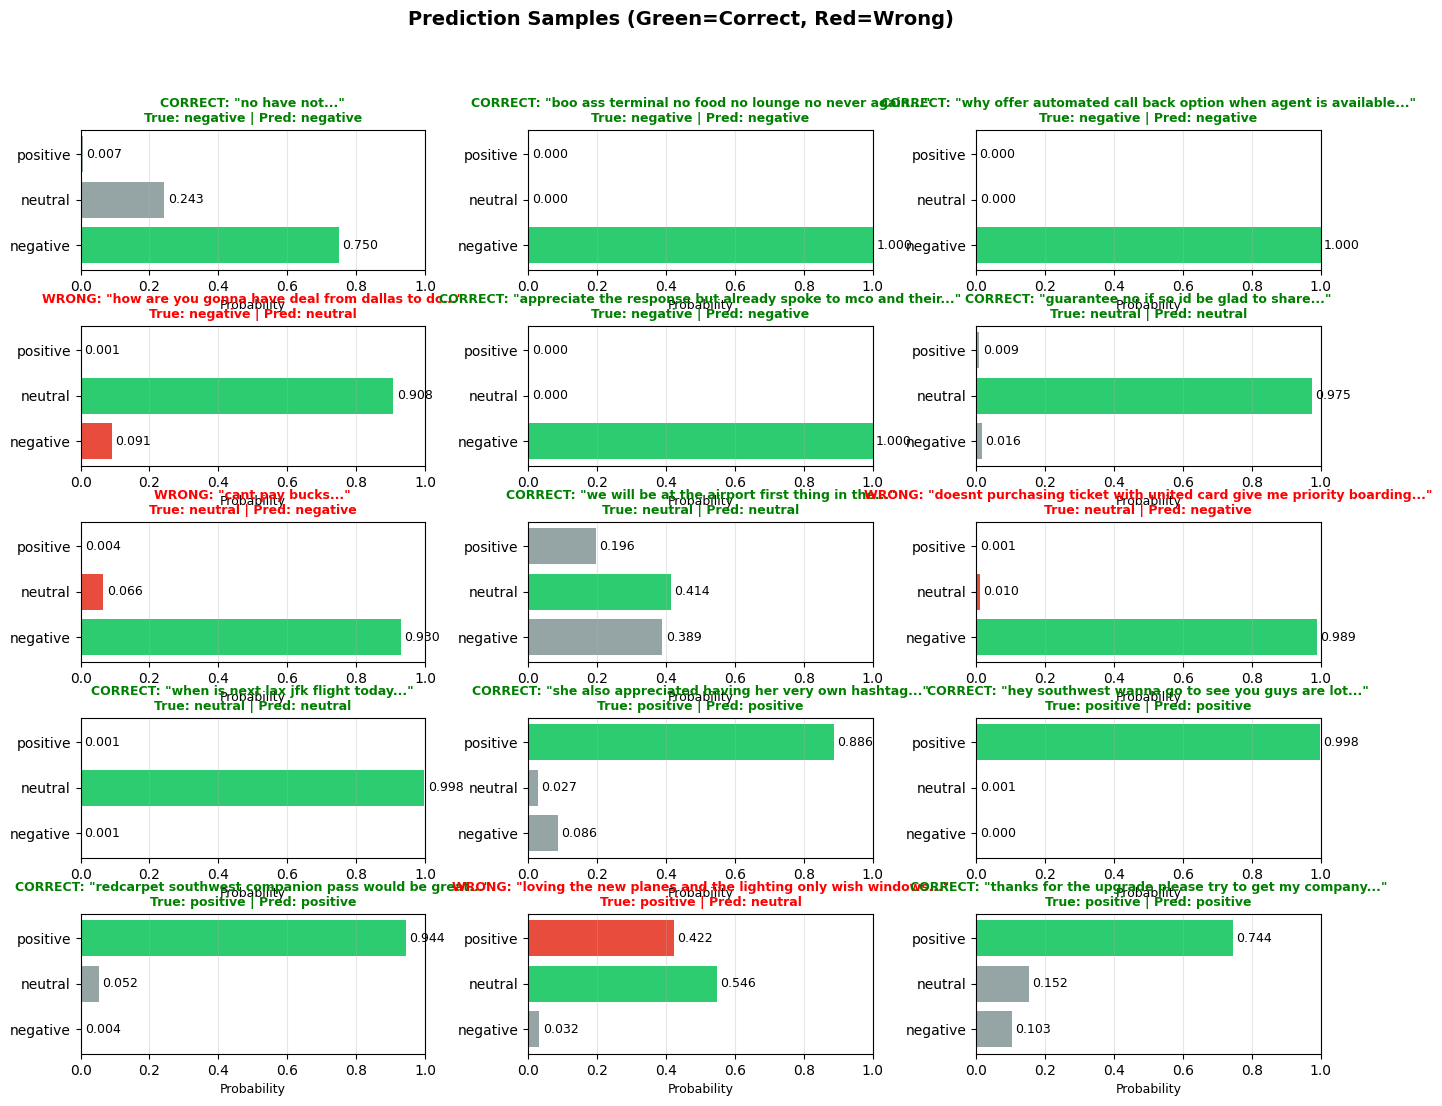


DETAILED PREDICTION EXAMPLES

1. Text: no have not...
   True: negative   | Predicted: negative  
   Probabilities: negative=0.750  neutral=0.243  positive=0.007  

2. Text: boo <UNK> ass terminal no food no lounge no <UNK> never again...
   True: negative   | Predicted: negative  
   Probabilities: negative=1.000  neutral=0.000  positive=0.000  

3. Text: why offer automated call back option when agent is available only to call me amp have me sit on hold at am <UNK>...
   True: negative   | Predicted: negative  
   Probabilities: negative=1.000  neutral=0.000  positive=0.000  

4. Text: how are you gonna have deal from dallas to dc but no deal from dc to dallas sad...
   True: negative   | Predicted: neutral   
   Probabilities: negative=0.091  neutral=0.908  positive=0.001  
   MISCLASSIFICATION!

5. Text: appreciate the response but already spoke to mco and their response was there is nothing we can do idk if thats what you mean...
   True: negative   | Predicted: negative  
   Pro

In [33]:
print("Generating prediction samples...\n")

# Get sample indices for each class
num_samples_per_class = 5
sample_indices = []

for label in range(CONFIG['NUM_CLASSES']):
    # Get indices where true label matches
    class_indices = np.where(all_labels == label)[0]
    # Sample random indices
    if len(class_indices) >= num_samples_per_class:
        selected = np.random.choice(class_indices, num_samples_per_class, replace=False)
        sample_indices.extend(selected)

# Create visualization
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(5, 3, hspace=0.4, wspace=0.3)

for idx, sample_idx in enumerate(sample_indices):
    row = idx // 3
    col = idx % 3
    ax = fig.add_subplot(gs[row, col])
    
    # Get data
    true_label = all_labels[sample_idx]
    pred_label = all_preds[sample_idx]
    probabilities = all_probs[sample_idx]
    
    # Get original text
    test_idx = sample_idx  # Index in test set
    sequence = X_test[test_idx]
    
    # Decode sequence back to text (first 10 words)
    words = []
    for word_idx in sequence[:15]:
        if word_idx in idx_to_word:
            word = idx_to_word[word_idx]
            if word not in ['<PAD>', '<UNK>']:
                words.append(word)
        if len(words) >= 10:
            break
    
    text_preview = ' '.join(words) + '...'
    
    # Determine if correct
    is_correct = (true_label == pred_label)
    
    # Plot probabilities
    colors = ['#2ecc71' if i == pred_label else '#95a5a6' for i in range(CONFIG['NUM_CLASSES'])]
    if not is_correct:
        colors[true_label] = '#e74c3c'  # Highlight true label in red
    
    bars = ax.barh(CONFIG['CLASS_NAMES'], probabilities, color=colors)
    
    # Add probability labels
    for i, (bar, prob) in enumerate(zip(bars, probabilities)):
        ax.text(prob + 0.01, i, f'{prob:.3f}', va='center', fontsize=9)
    
    ax.set_xlim([0, 1.0])
    ax.set_xlabel('Probability', fontsize=9)
    
    # Title with text preview
    title_color = 'green' if is_correct else 'red'
    status = "CORRECT" if is_correct else "WRONG"
    ax.set_title(
        f'{status}: "{text_preview}"\nTrue: {CONFIG["CLASS_NAMES"][true_label]} | Pred: {CONFIG["CLASS_NAMES"][pred_label]}',
        fontsize=9,
        color=title_color,
        fontweight='bold'
    )
    
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Prediction Samples (Green=Correct, Red=Wrong)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()

pred_samples_path = os.path.join(CONFIG['OUTPUT_DIR'], 'prediction_samples.png')
plt.savefig(pred_samples_path, dpi=300, bbox_inches='tight')
print(f"Prediction samples saved to: {pred_samples_path}")
plt.show()

# Print detailed samples
print("\n" + "="*80)
print("DETAILED PREDICTION EXAMPLES")
print("="*80)

for i, sample_idx in enumerate(sample_indices[:10], 1):  # Show first 10
    true_label = all_labels[sample_idx]
    pred_label = all_preds[sample_idx]
    probabilities = all_probs[sample_idx]
    
    # Get original text
    sequence = X_test[sample_idx]
    words = [idx_to_word[word_idx] for word_idx in sequence 
             if word_idx in idx_to_word and idx_to_word[word_idx] not in ['<PAD>']]
    text = ' '.join(words[:30]) + '...'
    
    print(f"\n{i}. Text: {text}")
    print(f"   True: {CONFIG['CLASS_NAMES'][true_label]:10s} | Predicted: {CONFIG['CLASS_NAMES'][pred_label]:10s}")
    print(f"   Probabilities: ", end='')
    for j, (name, prob) in enumerate(zip(CONFIG['CLASS_NAMES'], probabilities)):
        print(f"{name}={prob:.3f}", end='  ')
    print()
    
    if true_label != pred_label:
        print(f"   MISCLASSIFICATION!")

Generating confusion matrix...

Confusion matrix saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q2\Q2a_LSTM_Sentiment_PyTorch\confusion_matrix.png


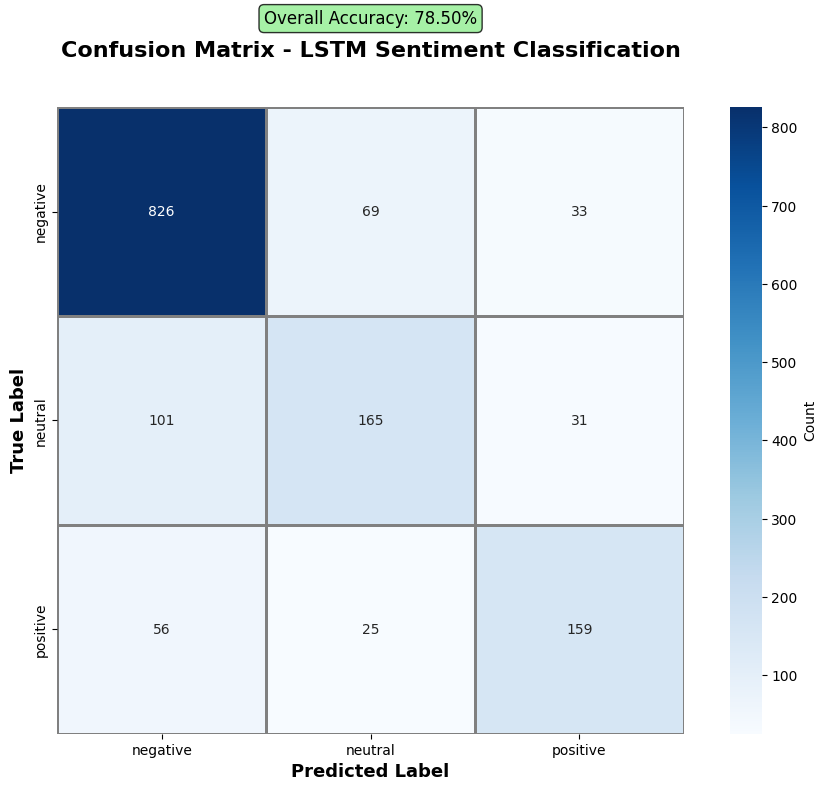


PER-CLASS METRICS

NEGATIVE:
   Accuracy:   89.01% (826/928)
   Precision: 0.8403
   Recall:    0.8901
   F1-Score:  0.8645

NEUTRAL:
   Accuracy:   55.56% (165/297)
   Precision: 0.6371
   Recall:    0.5556
   F1-Score:  0.5935

POSITIVE:
   Accuracy:   66.25% (159/240)
   Precision: 0.7130
   Recall:    0.6625
   F1-Score:  0.6868


In [34]:
print("Generating confusion matrix...\n")

# Calculate confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Create visualization
plt.figure(figsize=(10, 8))

# Plot heatmap
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=CONFIG['CLASS_NAMES'],
    yticklabels=CONFIG['CLASS_NAMES'],
    cbar_kws={'label': 'Count'},
    square=True,
    linewidths=1,
    linecolor='gray'
)

plt.title('Confusion Matrix - LSTM Sentiment Classification\n', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')

# Add accuracy annotation
plt.text(
    1.5, -0.4, 
    f'Overall Accuracy: {test_accuracy:.2f}%',
    fontsize=12,
    ha='center',
    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8)
)

plt.tight_layout()

# Save
cm_path = os.path.join(CONFIG['OUTPUT_DIR'], 'confusion_matrix.png')
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
print(f"Confusion matrix saved to: {cm_path}")
plt.show()

# Calculate per-class accuracy
print("\n" + "="*80)
print("PER-CLASS METRICS")
print("="*80)

for i, class_name in enumerate(CONFIG['CLASS_NAMES']):
    class_correct = cm[i, i]
    class_total = cm[i, :].sum()
    class_acc = 100. * class_correct / class_total if class_total > 0 else 0
    
    # Precision and recall for this class
    true_positives = cm[i, i]
    false_positives = cm[:, i].sum() - true_positives
    false_negatives = cm[i, :].sum() - true_positives
    
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"\n{class_name.upper()}:")
    print(f"   Accuracy:  {class_acc:6.2f}% ({class_correct}/{class_total})")
    print(f"   Precision: {precision:6.4f}")
    print(f"   Recall:    {recall:6.4f}")
    print(f"   F1-Score:  {f1:6.4f}")

Generating ROC curves...

ROC curves saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q2\Q2a_LSTM_Sentiment_PyTorch\roc_curves.png


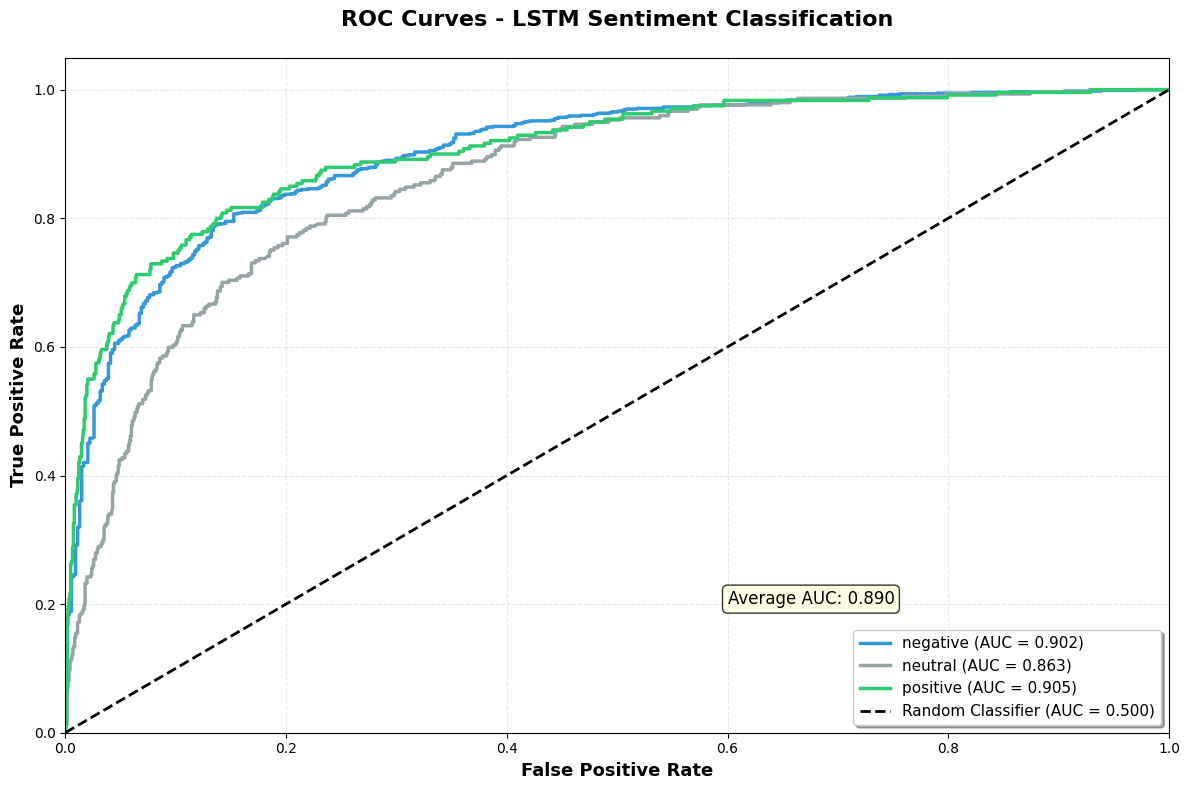


AUC SCORES
   negative  : 0.9021
   neutral   : 0.8625
   positive  : 0.9055

   Average   : 0.8900


In [35]:
print("Generating ROC curves...\n")

# Binarize labels for multiclass ROC
y_test_bin = label_binarize(all_labels, classes=range(CONFIG['NUM_CLASSES']))

# Create figure
plt.figure(figsize=(12, 8))

# Plot ROC curve for each class
colors = ['#3498db', '#95a5a6', '#2ecc71']
auc_scores = []

for i, (class_name, color) in enumerate(zip(CONFIG['CLASS_NAMES'], colors)):
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    
    # Plot
    plt.plot(
        fpr, tpr, 
        color=color, 
        lw=2.5,
        label=f'{class_name} (AUC = {roc_auc:.3f})'
    )

# Plot random classifier line
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC = 0.500)')

# Formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
plt.title('ROC Curves - LSTM Sentiment Classification\n', 
          fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)
plt.grid(alpha=0.3, linestyle='--')

# Add text box with average AUC
avg_auc = np.mean(auc_scores)
plt.text(
    0.6, 0.2,
    f'Average AUC: {avg_auc:.3f}',
    fontsize=12,
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)

plt.tight_layout()

# Save
roc_path = os.path.join(CONFIG['OUTPUT_DIR'], 'roc_curves.png')
plt.savefig(roc_path, dpi=300, bbox_inches='tight')
print(f"ROC curves saved to: {roc_path}")
plt.show()

# Print AUC scores
print("\n" + "="*80)
print("AUC SCORES")
print("="*80)

for class_name, auc_score in zip(CONFIG['CLASS_NAMES'], auc_scores):
    print(f"   {class_name:10s}: {auc_score:.4f}")
print(f"\n   {'Average':10s}: {avg_auc:.4f}")

Generating training history plots...

Training history saved to: C:\Users\yrghimire\Chapter\spring_2026\cse817\bigdata_act\chap3\outputs\Q2\Q2a_LSTM_Sentiment_PyTorch\training_history.png


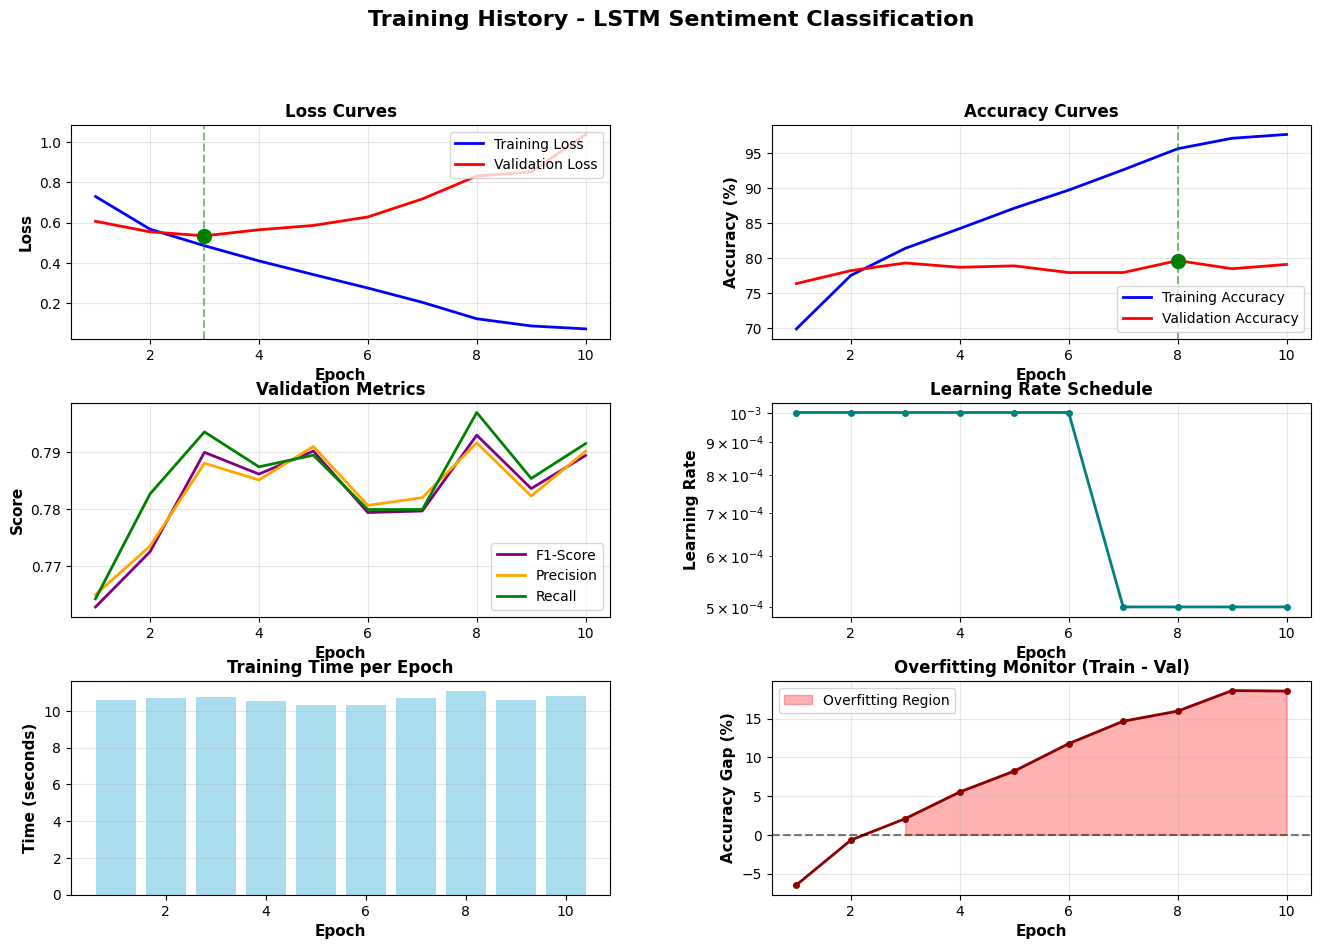


TRAINING SUMMARY STATISTICS

   Total epochs: 10
   Best validation accuracy: 79.70% (epoch 8)
   Best validation loss: 0.5348 (epoch 3)
   Best validation F1-score: 0.7930
   Final learning rate: 0.000500
   Average epoch time: 10.63s
   Total training time: 1.77 minutes


In [36]:
print("Generating training history plots...\n")

# Load training history
history = metric_tracker.history

# Create comprehensive visualization
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Loss curves
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history['epoch'], history['train_loss'], 'b-', linewidth=2, label='Training Loss')
ax1.plot(history['epoch'], history['val_loss'], 'r-', linewidth=2, label='Validation Loss')
ax1.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=11, fontweight='bold')
ax1.set_title('Loss Curves', fontsize=12, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(alpha=0.3)

# Mark best epoch
best_epoch_idx = history['val_loss'].index(min(history['val_loss']))
ax1.axvline(x=history['epoch'][best_epoch_idx], color='g', linestyle='--', alpha=0.5, label='Best Model')
ax1.plot(history['epoch'][best_epoch_idx], history['val_loss'][best_epoch_idx], 
         'go', markersize=10)

# 2. Accuracy curves
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(history['epoch'], history['train_acc'], 'b-', linewidth=2, label='Training Accuracy')
ax2.plot(history['epoch'], history['val_acc'], 'r-', linewidth=2, label='Validation Accuracy')
ax2.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
ax2.set_title('Accuracy Curves', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(alpha=0.3)

# Mark best epoch
best_acc_idx = history['val_acc'].index(max(history['val_acc']))
ax2.axvline(x=history['epoch'][best_acc_idx], color='g', linestyle='--', alpha=0.5)
ax2.plot(history['epoch'][best_acc_idx], history['val_acc'][best_acc_idx], 
         'go', markersize=10)

# 3. F1, Precision, Recall
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(history['epoch'], history['val_f1'], 'purple', linewidth=2, label='F1-Score')
ax3.plot(history['epoch'], history['val_precision'], 'orange', linewidth=2, label='Precision')
ax3.plot(history['epoch'], history['val_recall'], 'green', linewidth=2, label='Recall')
ax3.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax3.set_ylabel('Score', fontsize=11, fontweight='bold')
ax3.set_title('Validation Metrics', fontsize=12, fontweight='bold')
ax3.legend(loc='lower right')
ax3.grid(alpha=0.3)

# 4. Learning rate schedule
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(history['epoch'], history['learning_rate'], 'teal', linewidth=2, marker='o', markersize=4)
ax4.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax4.set_ylabel('Learning Rate', fontsize=11, fontweight='bold')
ax4.set_title('Learning Rate Schedule', fontsize=12, fontweight='bold')
ax4.set_yscale('log')
ax4.grid(alpha=0.3)

# 5. Epoch time
ax5 = fig.add_subplot(gs[2, 0])
ax5.bar(history['epoch'], history['epoch_time'], color='skyblue', alpha=0.7)
ax5.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax5.set_ylabel('Time (seconds)', fontsize=11, fontweight='bold')
ax5.set_title('Training Time per Epoch', fontsize=12, fontweight='bold')
ax5.grid(alpha=0.3, axis='y')

# 6. Train vs Val gap
ax6 = fig.add_subplot(gs[2, 1])
gap = [train - val for train, val in zip(history['train_acc'], history['val_acc'])]
ax6.plot(history['epoch'], gap, 'darkred', linewidth=2, marker='o', markersize=4)
ax6.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax6.fill_between(history['epoch'], 0, gap, where=[g > 0 for g in gap], 
                 color='red', alpha=0.3, label='Overfitting Region')
ax6.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax6.set_ylabel('Accuracy Gap (%)', fontsize=11, fontweight='bold')
ax6.set_title('Overfitting Monitor (Train - Val)', fontsize=12, fontweight='bold')
ax6.legend(loc='upper left')
ax6.grid(alpha=0.3)

# Main title
fig.suptitle('Training History - LSTM Sentiment Classification', 
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()

# Save
history_path = os.path.join(CONFIG['OUTPUT_DIR'], 'training_history.png')
plt.savefig(history_path, dpi=300, bbox_inches='tight')
print(f"Training history saved to: {history_path}")
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("TRAINING SUMMARY STATISTICS")
print("="*80)

print(f"\n   Total epochs: {len(history['epoch'])}")
print(f"   Best validation accuracy: {max(history['val_acc']):.2f}% (epoch {best_acc_idx + 1})")
print(f"   Best validation loss: {min(history['val_loss']):.4f} (epoch {best_epoch_idx + 1})")
print(f"   Best validation F1-score: {max(history['val_f1']):.4f}")
print(f"   Final learning rate: {history['learning_rate'][-1]:.6f}")
print(f"   Average epoch time: {np.mean(history['epoch_time']):.2f}s")
print(f"   Total training time: {sum(history['epoch_time'])/60:.2f} minutes")